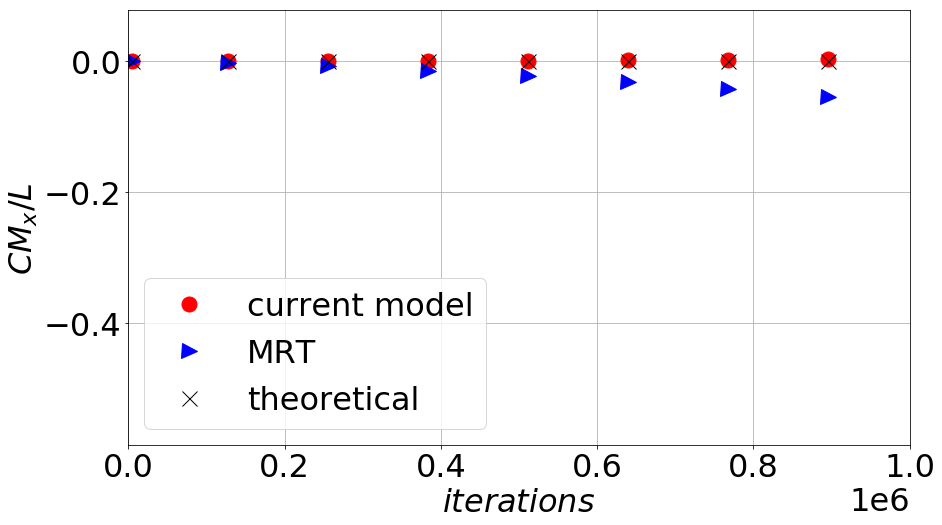

In [15]:
import matplotlib.pyplot as plt
import os
#from utilites import read_data_from_timestep
import numpy as np
import pandas as pd
import csv


rho_ratio = '1'
v = '001'
U='001'

folder_path_moving = os.path.join("~/DATA_FOR_PLOTS",
                           "moving_vs_resting_bubble",
                           f"rho{rho_ratio}_v{v}_circular_U{U}",
                           "line_data")


frames_cm = []
frames_mrt = []

n = np.arange(127, 999, 128)  # U0 = 0.01
# n = np.arange(234, 999, 235) # Ma=0.1 
# n = np.arange(46, 999, 47)  # Ma=0.5
i = np.arange(len(n))

u_diff = np.empty(len(n))
rho_diff = np.empty(len(n))

pf_cm_CMx = np.empty(len(n))  # x coordinate of the center of mass of the bubble
pf_mrt_CMx = np.empty(len(n))  # x coordinate of the center of mass of the bubble

domain_size = 256
bubble_diam = 56
for i_, n_ in zip(i, n):
    frame_cm = pd.read_csv(os.path.join(folder_path_moving, "cm_moving.%d.csv" % n_), delimiter=",")
    frame_mrt = pd.read_csv(os.path.join(folder_path_moving, "mrt_moving.%d.csv" % n_), delimiter=",")

    frames_cm.append(frame_cm)
    frames_mrt.append(frame_mrt)

    def find_CMx(pf, arc_x, n_, threshold=0.5):
        scale_factor = 1001/domain_size  
        counter = 0
        weight = 0
#         arc_x = np.roll(arc_x, U0*n*1001)
        bubble_edge = (domain_size + bubble_diam)/2
        bubble_edge = domain_size * 0.75
        for pf_, x_cm in zip(pf, arc_x):
            if pf_ > threshold:
                if x_cm > bubble_edge:
                    x_cm -= 256

                counter += x_cm*pf_
                weight += pf_

        ans = counter/weight
        return ans

    pf_cm_CMx[i_] = find_CMx(frame_cm['PhaseField'], frame_cm['arc_length'], n_)
    pf_mrt_CMx[i_] = find_CMx(frame_mrt['PhaseField'], frame_mrt['arc_length'], n_)

# pf_cm_CMx -= 3
# pf_mrt_CMx -= 3

pf_cm_CMx -= domain_size/2
pf_mrt_CMx -= domain_size/2

n = np.insert(n, 0, 5) # insert a point at front (index 0)
pf_cm_CMx = np.insert(pf_cm_CMx, 0, 0)
pf_mrt_CMx= np.insert(pf_mrt_CMx, 0, 0)

theoretical = np.arange(len(n), dtype='float')
theoretical.fill(0)
# make plot
plt.rcParams.update({'font.size': 32})
plt.figure(figsize=(14, 8))
plt.plot(n*1E3, pf_cm_CMx/domain_size, color="red", marker="o", markersize=15, linestyle="", label=r'current model')
plt.plot(n*1E3, pf_mrt_CMx/domain_size, color="blue", marker=">", markersize=15,  linestyle="", label=r'MRT')
plt.plot(n*1E3, theoretical/domain_size, color="black", marker="x", markersize=15, linestyle="", label=r'theoretical')

axes = plt.gca()
axes.set_xlim([0, 1E6])
axes.set_ylim([-150/domain_size, 20/domain_size])

# plt.plot(frames_cm[0]['arc_length'], frames_cm[0]['PhaseField'], color="green", marker="x", linestyle="",  label='test')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.ylabel(r'$CM_x/L$')
plt.xlabel(r'$iterations$')

# plt.title('Bubble\'s center of the mass')
plt.grid(True)
plt.legend()
fig = plt.gcf()  # get current figure

fig.savefig('CMx_rho%s_v%s_U%s.png' % (rho_ratio, v, U))

plt.show()
plt.close(fig)    # close the figure


In [55]:
a = np.array([1,2,3,4])
a
np.insert(a,0,-10)

array([-10,   1,   2,   3,   4])